# Conditional Variational Autoencoder

![VAE](notebook_images/cvae.jpg)

When using a VAE or a vanilla autoencoder, we have no control of what is generated when providing a latent space element to the decoder. Conditional VAEs address this issue by adding a condition during training. This condition can be the class label, or a set of features. 

By conditioning the output, exploring the latent space provides meaningful variation based on the specified condition. For instance, if the condition is a class label, then the CVAE is expected to generate samples corresponding to that class.

Although the original paper proposes using the condition both at the encoder and the decoder, in practice, for some applications it is sufficient to add the condition only at the latent space.  This approach is efficient and works well for standard class-conditional generation tasks. However, for more complex scenarios or when fine-grained control is needed, injecting the condition earlier in the encoder (e.g., at the input or via feature-wise modulation) may be beneficial.

**Original paper:**

Learning Structured Output Representation using Deep Conditional Generative Models, Kihyuk Sohn, Xinchen Yan, Honglak Lee - Auto-Encoding Variational Bayes - https://proceedings.neurips.cc/paper_files/paper/2015/file/8d55a249e6baa5c06772297520da2051-Paper.pdf

**Further reading:**

Understanding Conditional Variational Autoencoders - https://theaiacademy.blogspot.com/2020/05/understanding-conditional-variational.html





In [132]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Rectangle

import numpy as np
import time

import os
import pathlib
from PIL import Image
import skimage
from tqdm import tqdm

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

In [133]:
print(torch.__version__)

2.2.1+cu118


## Aux functions

Note: the training function is based on the VAE training function. Modifications are clearly marked with # --- CHANGED: ....

In [134]:
from matplotlib import colors

def plot_scatter(x,y,targets):
    cmap = colors.ListedColormap(['black', 'darkred', 'darkblue', 
                                  'darkgreen', 'yellow', 'brown', 
                                  'purple', 'lightgreen', 'red', 'lightblue'])
    bounds=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5,8.5,9.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(12,10))
    plt.scatter(x, y, c = targets, cmap=cmap, s = 1, norm=norm)
    plt.colorbar()

    plt.show()


def show_preds(set1, set2, count):
  
  columns = 4
  rows = int(count*2 / columns) + 1  
  plt.figure(figsize=(count, 2 * rows))
  
  for n in range(count):
      ax = plt.subplot(rows, columns, n*2+1)
      plt.title("original")
      plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray)
      plt.axis('off')
      ax = plt.subplot(rows, columns, n*2+2)
      plt.title("reconstruction")
      plt.imshow(np.transpose(set2[n].cpu().detach().numpy(), (1,2,0)), cmap=plt.cm.gray)
      plt.axis('off')      


def train_cvae(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix='model', beta=1.0, num_classes=10):
    
    history = {'loss': [], 'val_loss': [], 'val_recon': [], 'val_kl': []}
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        start_time = time.time()
        running_loss = 0.0
        total_train_samples = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):

            inputs, labels = batch
            targets = inputs
            # --------------------------------------------------------------
                
            inputs = inputs.to(device)
            targets = targets.to(device)
            labels = labels.to(device)
            
            batch_size = inputs.size(0)
            
            optimizer.zero_grad()
            
            # --- CHANGED: apply CVAE one-hot condition ---
            condition = torch.nn.functional.one_hot(labels, num_classes=num_classes).float()
            outputs, mean, log_var = model(inputs, condition)
            # ----------------------------------------------------
            
            # loss function requires targets, outputs, and latent parameters
            loss, rloss, klloss = loss_fn(targets, outputs, mean, log_var, beta=beta)
            
            loss.backward()
            optimizer.step()
            
            # Accumulate loss (weighted by batch size for accuracy on final incomplete batch)
            running_loss += loss.item() * batch_size
            total_train_samples += batch_size
            
        epoch_loss = running_loss / total_train_samples
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_recon_loss = 0.0
        val_kl_loss = 0.0
        total_val_samples = 0
        
        with torch.no_grad():
            for batch in val_loader:

                inputs, labels = batch
                targets = inputs
                # --------------------------------------------------------------
                    
                inputs = inputs.to(device)
                targets = targets.to(device)
                labels = labels.to(device)
                batch_size = inputs.size(0)
                
                # --- CHANGED: apply CVAE one-hot condition ---
                condition = torch.nn.functional.one_hot(labels, num_classes=num_classes).float()
                outputs, mean, log_var = model(inputs, condition)
                # ----------------------------------------------------
                
                batch_loss, batch_rloss, batch_klloss = loss_fn(targets, outputs, mean, log_var, beta=beta)
                
                val_loss += batch_loss.item() * batch_size
                val_recon_loss += batch_rloss.item() * batch_size
                val_kl_loss += batch_klloss.item() * batch_size
                total_val_samples += batch_size
                
        epoch_val_loss = val_loss / total_val_samples
        epoch_val_recon = val_recon_loss / total_val_samples
        epoch_val_kl = val_kl_loss / total_val_samples
        
        # --- Scheduling and Logging ---
        old_lr = optimizer.param_groups[0]['lr']
        # Assuming scheduler is a ReduceLROnPlateau based on your step argument
        scheduler.step(epoch_val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print(f'==> Learning rate updated: {old_lr:.6f} -> {new_lr:.6f}')
            
        stop_time = time.time()
        print(f'Epoch: {epoch:03d} | Loss: {epoch_loss:.6f} | Val Loss: {epoch_val_loss:.6f} '
              f'(Recon: {epoch_val_recon:.4f}, KL: {epoch_val_kl:.4f}) | Time: {(stop_time - start_time):.4f}s')
        
        history['loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_recon'].append(epoch_val_recon)
        history['val_kl'].append(epoch_val_kl)
        
        # --- Saving Best Model ---
        if epoch_val_loss < best_val_loss:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'history': history,
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'beta': beta
            }, f'{save_prefix}_best.pt')
            best_val_loss = epoch_val_loss
            
        # --- Early Stopping ---
        # Assuming early_stopper is a custom callable class/function
        if early_stopper(epoch_val_loss):
            print('Early stopping triggered!')
            break
            
    print('Finished Training')
    return history



class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False


def load_model(latent_space_dim):

    reload = torch.load(f'{MODEL_PATH}/cvae_{latent_space_dim}_best.pt')
    print(reload['epoch'])
    model = CVAE(Encoder(latent_space_dim, 10), Decoder(latent_space_dim, 10))
    model.to(device)
    model.load_state_dict(reload['model_state_dict'])
    return model


def one_hot(labels, class_size):
    targets = torch.zeros(labels.size(0), class_size)
    for i, label in enumerate(labels):
        targets[i, label] = 1
    return targets.to(device)    

## Configuration

In [135]:
HEIGHT = 28
WIDTH = 28
NUM_CHANNELS = 1
BATCH_SIZE = 128
LATENT_SPACE_DIM = 2

MODEL_PATH = 'cvae_models'

TRAIN = False

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


## Load and prepare MNIST dataset

In [136]:
transform = transforms.Compose(
    [transforms.ToTensor()]) 
train_set = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                          shuffle=True)

test_set = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                         shuffle=False)

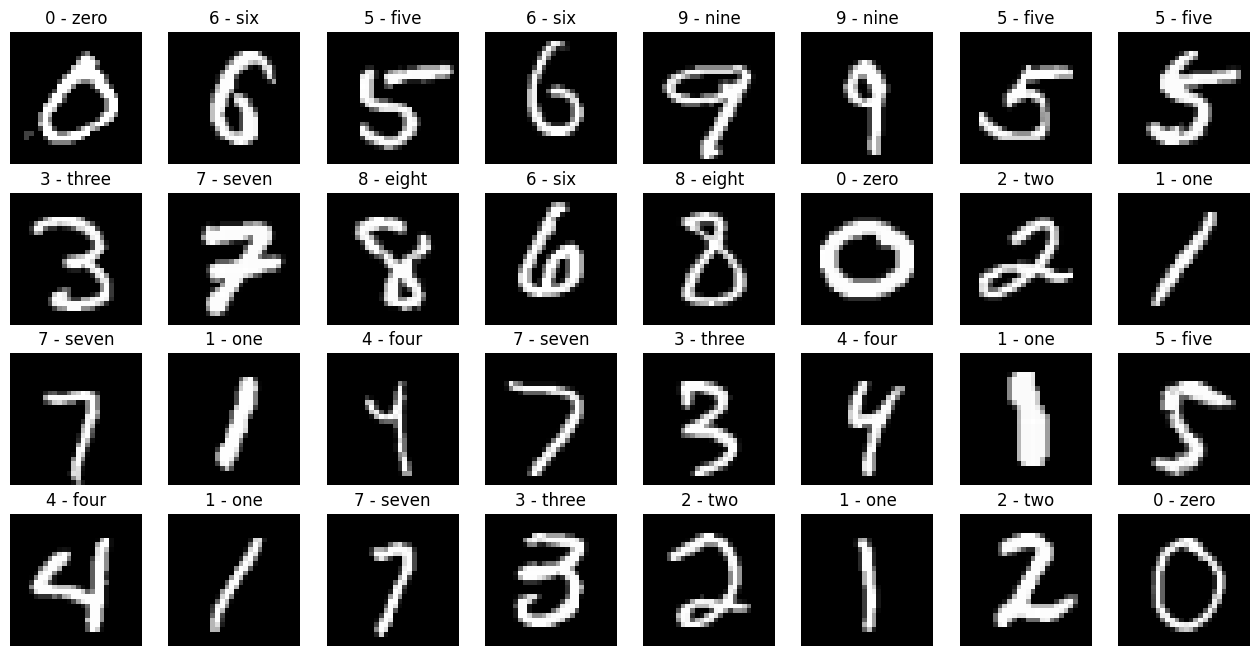

<Figure size 640x480 with 0 Axes>

In [137]:
images, targets = next(iter(train_loader))

vcpi_util.show_images(4,8, images, targets, train_set.classes) 

## Architecture

When defining the architecture, we're going to start with the VAE architecture explored in the previous notebook. Changes are marked with # --- CVAE CHANGE

In [138]:

class Encoder(nn.Module):
    # --- CVAE CHANGE: Added num_classes ---
    def __init__(self, latent_space_dim, num_classes):
        super().__init__()

        # --- First Convolutional Block ---
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()

        # --- Second Convolutional Block ---
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()

        # --- Latent Space Projections ---
        # Flattened size: 64 channels * 7 width * 7 height = 3136
        # --- CVAE CHANGE: Expanded input dimension to accommodate the condition vector ---
        self.fc_mean = nn.Linear(3136 + num_classes, latent_space_dim)
        self.fc_log_var = nn.Linear(3136 + num_classes, latent_space_dim)

    # --- CVAE CHANGE: Added condition 'c' to forward pass ---
    def forward(self, x, c):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        x = torch.flatten(x, 1)
        
        # --- CVAE CHANGE: Late Fusion - concatenate flattened image features with condition ---
        x = torch.cat([x, c], dim=1)
        
        mean = self.fc_mean(x)
        log_var = self.fc_log_var(x)

        return mean, log_var


The decoder's input is the  latent space vector and the condition

In [139]:
class Decoder(nn.Module):
    # --- CVAE CHANGE: Added num_classes ---
    def __init__(self, latent_space_dim, num_classes):
        super().__init__()

        # --- Latent Space Projection ---
        # --- CVAE CHANGE: Expanded input dimension to accommodate the condition vector ---
        self.fc_latent = nn.Linear(latent_space_dim + num_classes, 3136)
        
        # --- First Transposed Convolutional Block ---
        self.convT1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, 
                                         kernel_size=3, stride=2, 
                                         padding=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()

        # --- Second Transposed Convolutional Block ---
        self.convT2 = nn.ConvTranspose2d(in_channels=32, out_channels=1, 
                                         kernel_size=3, stride=2, 
                                         padding=1, output_padding=1)
        self.sigmoid = nn.Sigmoid()

    # --- CVAE CHANGE: Renamed 'x' to 'z' for clarity, added condition 'c' ---
    def forward(self, z, c):
        # --- CVAE CHANGE: Late Fusion - concatenate latent vector with condition ---
        z = torch.cat([z, c], dim=1)
        
        x = self.fc_latent(z)
        x = x.view(-1, 64, 7, 7)
        
        x = self.convT1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.convT2(x)
        x = self.sigmoid(x)

        return x

In [140]:
class CVAE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def reparametrization(self, mean, std):
        epsilon = torch.randn_like(mean)    
        z = mean + std * epsilon  
        return z  

    # --- CVAE CHANGE: Added condition 'c' to forward pass ---
    def forward(self, x, c):
        # --- CVAE CHANGE: Pass 'c' to encoder ---
        mean, log_var = self.encoder(x, c)
        
        std = torch.exp(0.5 * log_var)
        
        if self.training:
            z = self.reparametrization(mean, std)
        else:
            z = mean 
            
        # --- CVAE CHANGE: Pass 'c' to decoder ---
        output = self.decoder(z, c)

        return output, mean, log_var

In [141]:
encoder = Encoder(LATENT_SPACE_DIM, 10)
decoder = Decoder(LATENT_SPACE_DIM, 10)

model = CVAE(encoder=encoder, decoder=decoder).to(device)
model.to(device)

torchinfo.summary(model, input_size=[(BATCH_SIZE, 1, 28, 28),(BATCH_SIZE, 10)], col_names=["kernel_size", "input_size", "output_size", "num_params", "mult_adds"])



Layer (type:depth-idx)                   Kernel Shape              Input Shape               Output Shape              Param #                   Mult-Adds
CVAE                                     --                        [128, 1, 28, 28]          [128, 1, 28, 28]          --                        --
├─Encoder: 1-1                           --                        [128, 1, 28, 28]          [128, 2]                  --                        --
│    └─Conv2d: 2-1                       [3, 3]                    [128, 1, 28, 28]          [128, 32, 14, 14]         320                       8,028,160
│    └─BatchNorm2d: 2-2                  --                        [128, 32, 14, 14]         [128, 32, 14, 14]         64                        8,192
│    └─ReLU: 2-3                         --                        [128, 32, 14, 14]         [128, 32, 14, 14]         --                        --
│    └─Conv2d: 2-4                       [3, 3]                    [128, 32, 14, 14]         [1

## Loss function

In [142]:
BCE_loss = torch.nn.BCELoss(reduction = 'sum')

def loss_function(x, output, mean, log_var, beta = 1.0):
    reproduction_loss = BCE_loss(output, x)
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + beta *  KLD, reproduction_loss, KLD

optimizer = torch.optim.Adam(model.parameters())

## Training

In [143]:
if TRAIN:
    EPOCHS = 100
    LATENT_DIMS = [2,16]
    
    # Dummy early stopper since it wasn't in the original notebook
    dummy_early_stopper = lambda val_loss: False 
    
    for latent_dim in LATENT_DIMS:
        print(f"\n{'='*50}")
        print(f"Start training CVAE with LATENT_SPACE_DIM = {latent_dim}...")
        print(f"{'='*50}")
        
        # 1. Instantiate the architecture for the current latent dimension
        encoder = Encoder(latent_dim, 10)
        decoder = Decoder(latent_dim, 10)
        model = CVAE(encoder, decoder).to(device)
        
        # 2. Instantiate optimizer and scheduler for the current model
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
        
        # 3. Define save prefix using the current latent dimension
        save_prefix = f"{MODEL_PATH}/cvae_{latent_dim}"
        
        # 4. Call the training function
        # (Using test_loader as the val_loader argument)
        history = train_cvae(
            model=model,
            train_loader=train_loader,
            val_loader=test_loader, 
            epochs=EPOCHS,
            loss_fn=loss_function, 
            optimizer=optimizer,
            scheduler=scheduler,
            early_stopper=dummy_early_stopper,
            save_prefix=save_prefix,
            beta=1.0,
            num_classes=10
        )
        
        print(f"Finished training for LATENT_SPACE_DIM = {latent_dim}!!")

## Evaluating

In [144]:
LATENT_SPACE_DIM = 16

model = load_model(LATENT_SPACE_DIM)

78


### Testing reconstruction results in the test set

The reconstructed digits are clearly from the correct class, however, it is noticeable that the model is not performing a faithful reconstruction of the input image.

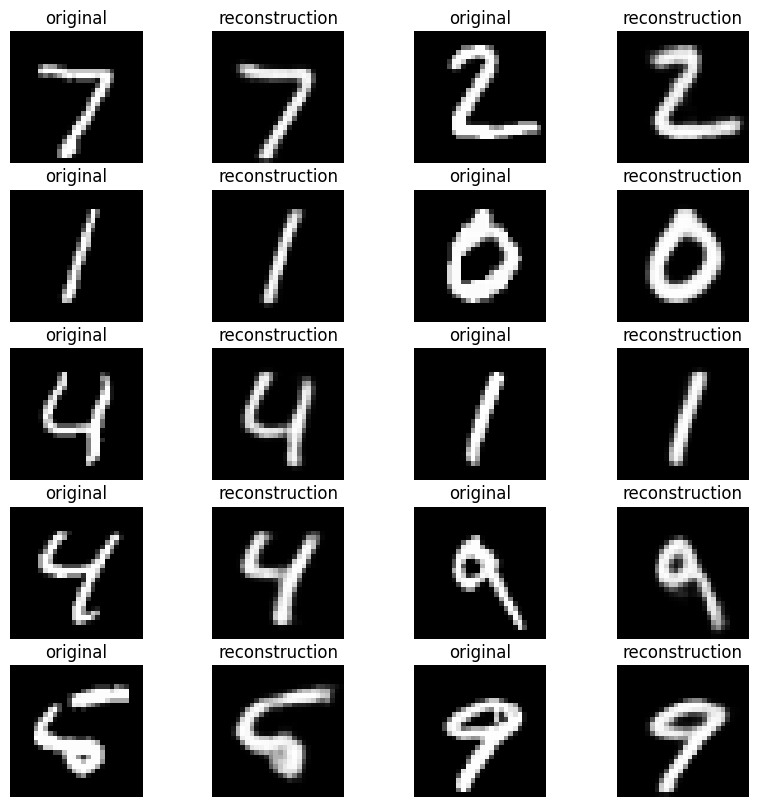

In [145]:
i, t = next(iter(test_loader))
recon,_,_ = model(i.to(device),one_hot(t,10))
    
show_preds(i, recon, 10)

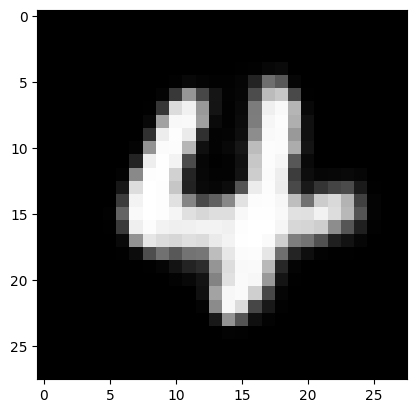

In [146]:
z = torch.Tensor([np.random.random_sample(size = LATENT_SPACE_DIM)]).to(device)
cond = torch.nn.functional.one_hot(torch.tensor([4]), 10).to(device)
pred = model.decoder(z, cond)
plt.imshow(np.transpose(pred[0].cpu().detach().numpy(), (1,2,0)), cmap=plt.cm.gray)

Checking the average latent space with LATENT_SPACE_DIM = 2

98


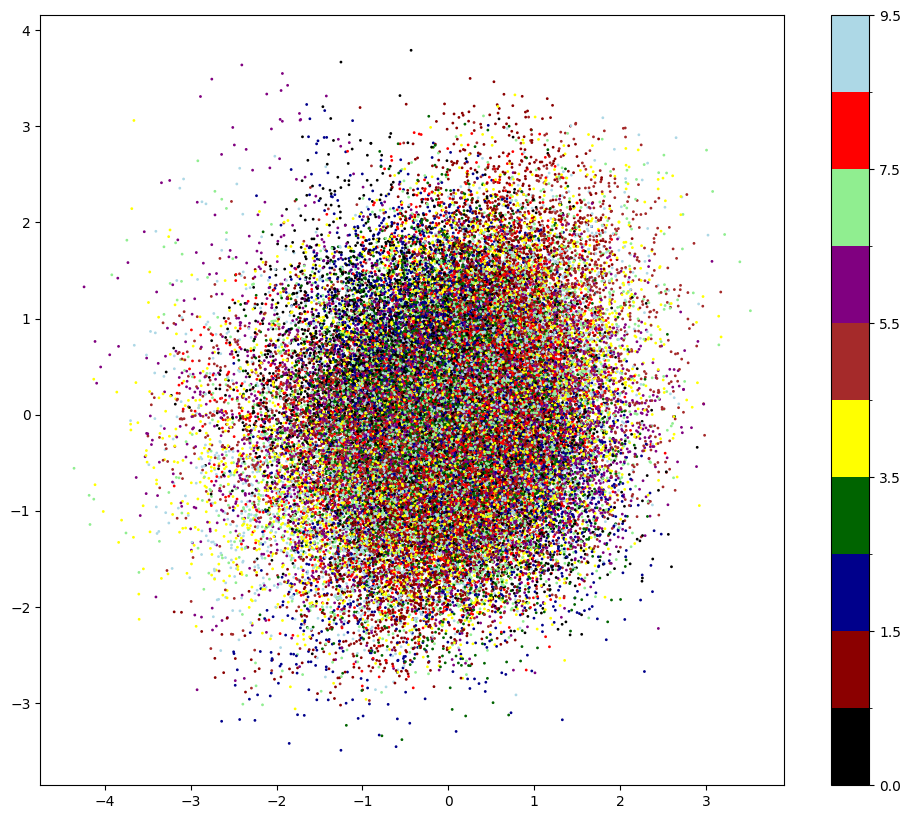

In [147]:
LATENT_SPACE_DIM = 2

model = load_model(LATENT_SPACE_DIM)

encoded_mean = []
encoded_log_var = []
targets = []
for i,t in train_loader:
    mean, log_var = model.encoder(i.to(device), one_hot(t,10))
    encoded_mean.extend(mean.cpu().detach().numpy())  
    encoded_log_var.extend(log_var.cpu().detach().numpy())
    targets.extend(t)

x = [m[0] for m in encoded_mean]
y = [m[1] for m in encoded_mean]

plot_scatter(x,y,targets)

### Note: The Geometry of the KL Penalty in CVAEs vs. VAEs

When analyzing the latent space of a Conditional VAE, it is crucial to understand that it behaves fundamentally differently than that of a standard VAE. The difference lies in how the KL-divergence penalty forces the network to organize the latent space $Z$.

The KL-divergence loss term used in a VAE to compute the differece between the encoder's distribution $q(z|x) \sim \mathcal{N}(\mu, \sigma^2)$ and the prior $p(z) \sim \mathcal{N}(0, 1)$ is:

<div align="center">

$\text{KL loss} = \frac{1}{B} \sum_{i=1}^{B} \left( \sum_{k=1}^{L} -0.5 \times \left( 1 + \log(\sigma_{ik}^2) - \mu_{ik}^2 - e^{\log(\sigma_{ik}^2)} \right) \right)$
</div>

Notice that this penalty is exactly zero only when the mean $\mu = 0$ and the variance $\sigma^2 = 1$. Any deviation from this origin incurs a strict numerical penalty.

1. The Standard VAE (Forced to pay the penalty)

In a standard VAE, the decoder only sees $z$. If the encoder maps all classes (0 through 9) to the exact same $\mathcal{N}(0,1)$ distribution, they will perfectly overlap in the center of the latent space. The decoder would receive a random point near the origin and have no idea which digit to draw.
To solve this, the encoder must separate the classes by shifting the means away from the origin (e.g., pushing the "0"s to $\mu = -3$) and shrinking the variance. The VAE willingly pays the KL penalty for doing this because it is the only way to minimize the Reconstruction Loss.

2. The CVAE (Refusing to pay the penalty)

In a CVAE, the decoder receives $z$ and the one-hot class label $y$.
Supoose the encoder tries to separate the classes in $Z$ just like the VAE did. It shifts the "0"s to $\mu = -3$, incurring a huge KL penalty. However, the decoder already has $y=[1, 0, 0...]$, so it already knows perfectly well to draw a "0".
Because the spatial separation in $Z$ did not improve the reconstruction loss, the optimizer realizes the $\mu = -3$ shift was a total waste of the KL penalty. Over the course of training, gradient descent actively pulls the means of all 10 classes back to $\mu = 0$ and expands their variances back to $\sigma^2 = 1$.

**Conclusion**

Because the CVAE doesn't need to separate the classes in $Z$ to get a good reconstruction, it refuses to pay the KL penalty to do so. Consequently, all 10 classes collapse perfectly on top of each other into a single, highly-overlapped $\mathcal{N}(0,1)$ blob.

This is why $Z$ in a CVAE represents only class-agnostic style (like rotation, slant, or stroke thickness). Style is the only variance left that the label $y$ doesn't explain, and therefore the only thing worth paying a KL penalty to encode!

### Visualizing the latent grid

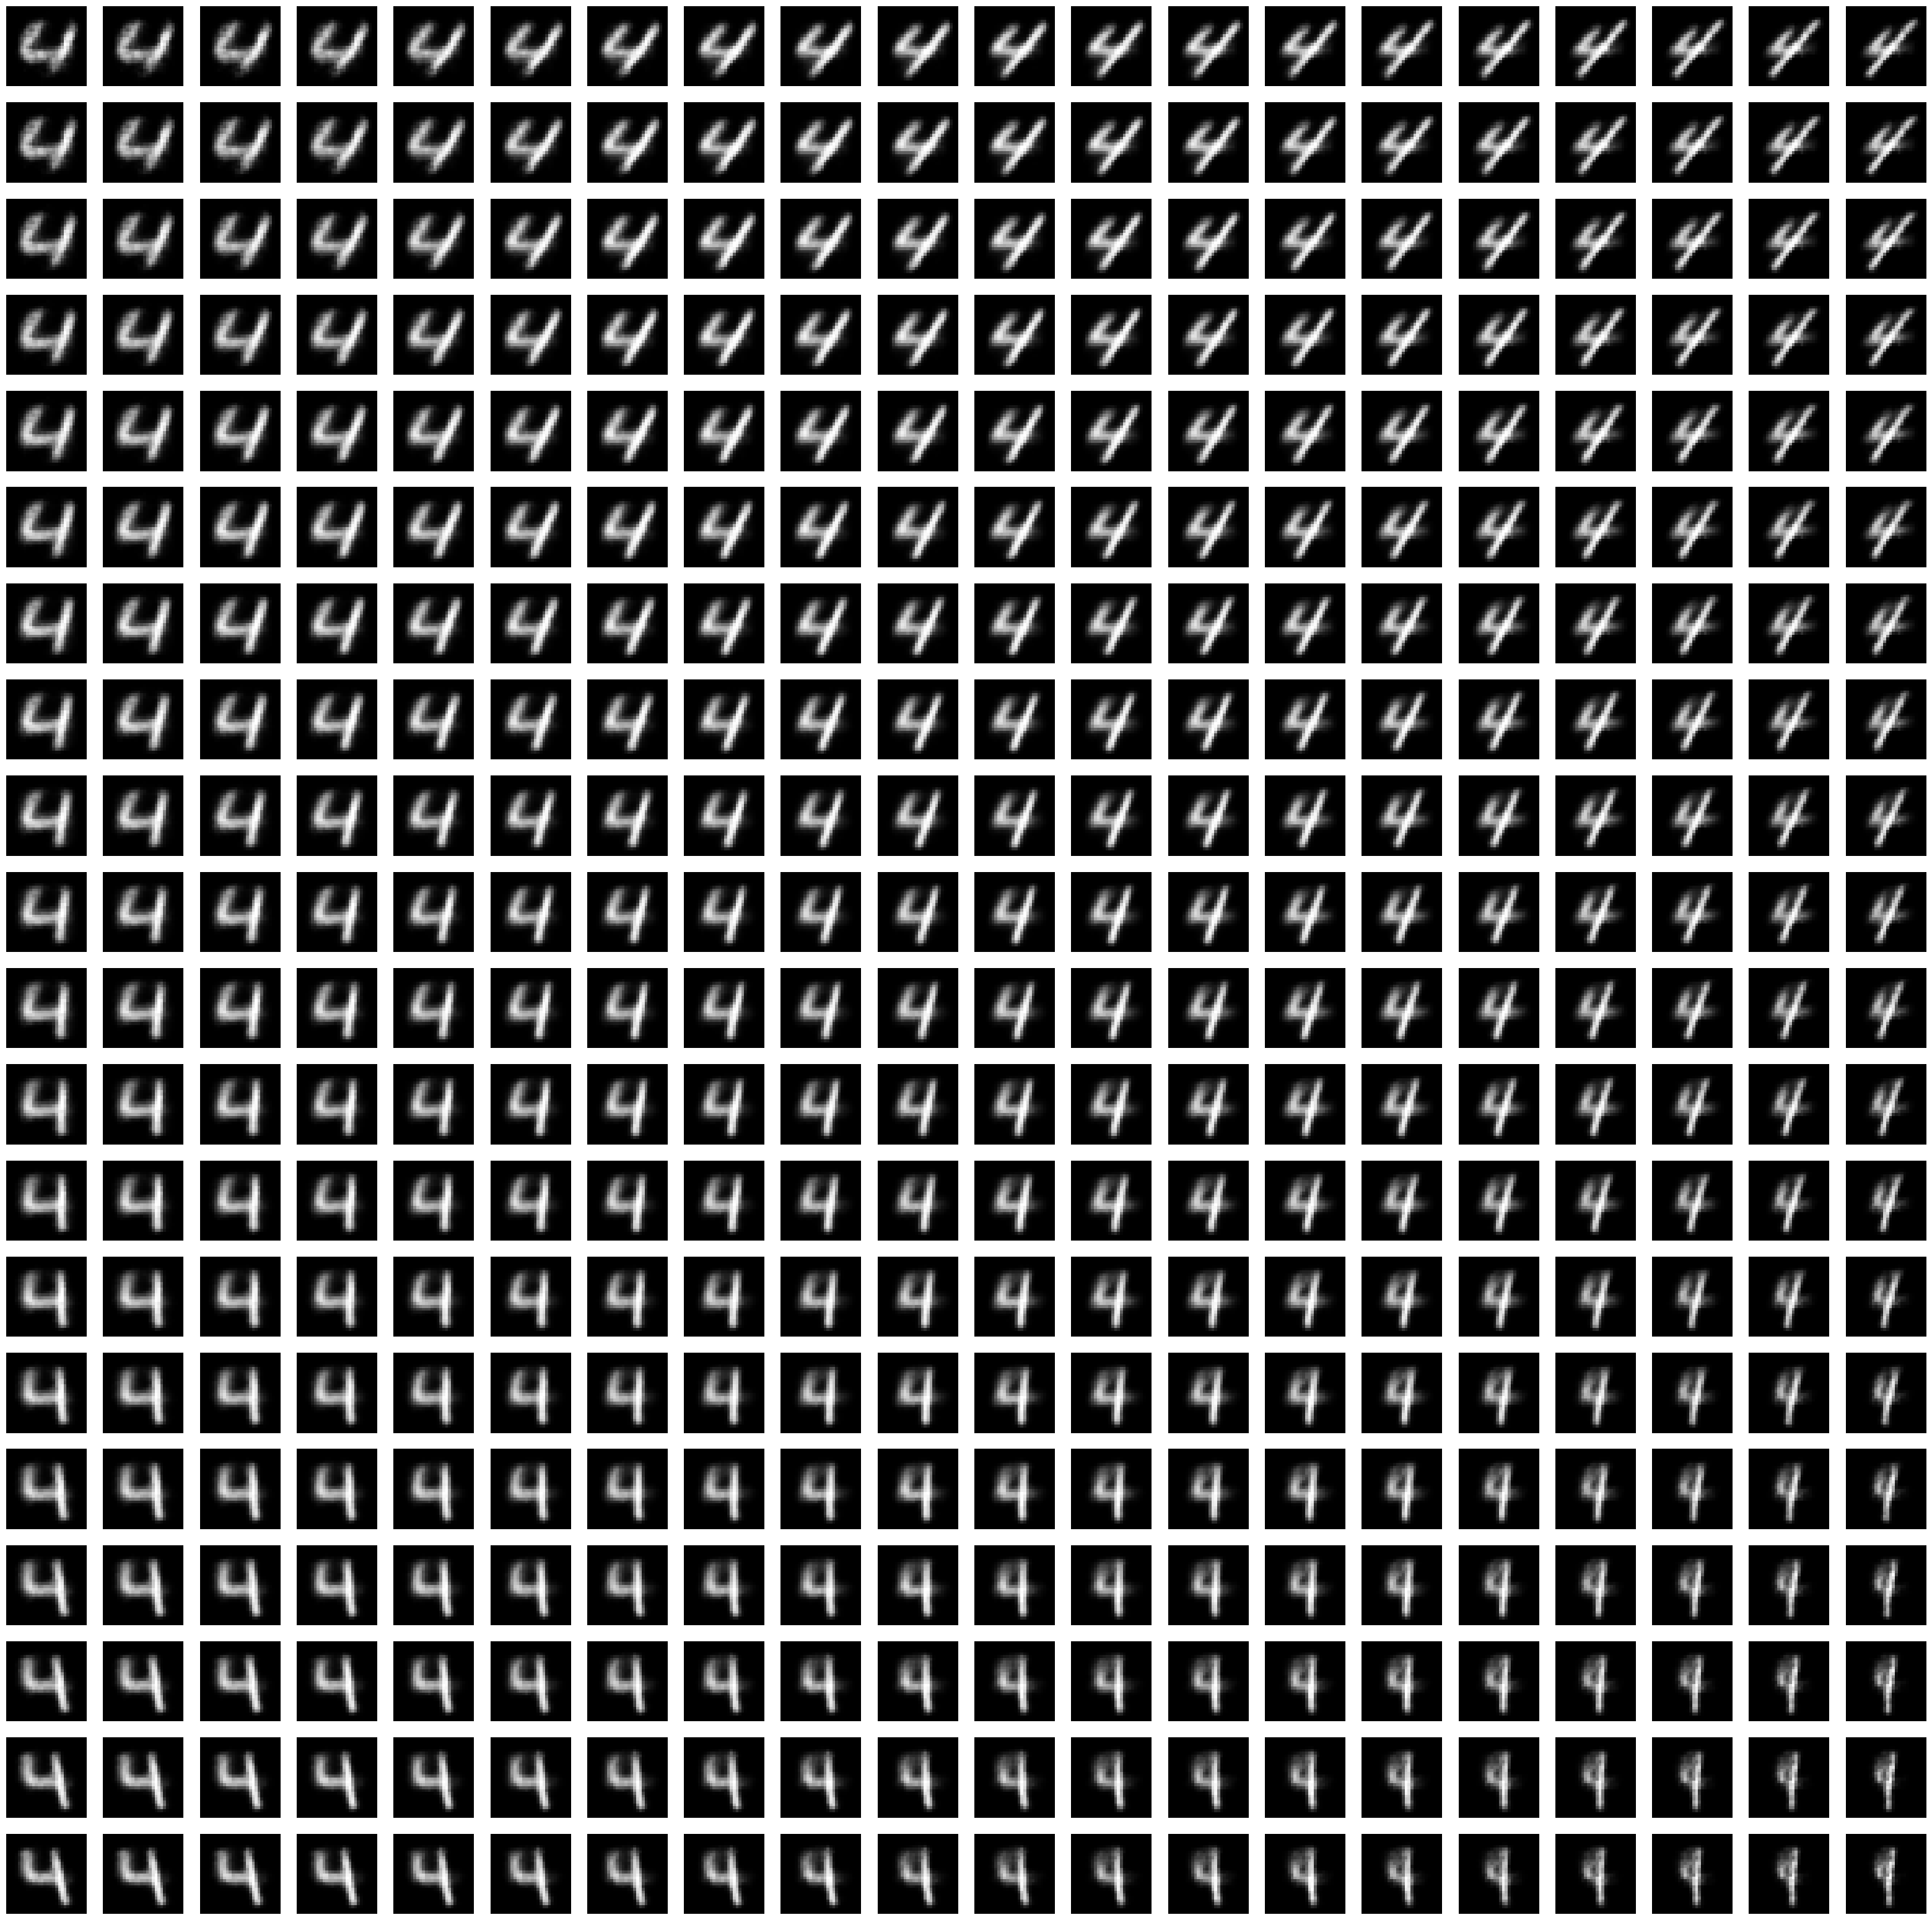

<Figure size 640x480 with 0 Axes>

In [148]:
if LATENT_SPACE_DIM == 2:
    limit = 2.0
    steps = 20
    number_class = 4

    # 1. Mathematically precise grid using PyTorch (faster, no loops)
    # y goes from +limit to -limit so the top-left image is (-2, 2)
    x = torch.linspace(-limit, limit, steps)
    y = torch.linspace(limit, -limit, steps)
    
    # Create the 2D grid
    grid_y, grid_x = torch.meshgrid(y, x, indexing='ij')
    
    # Flatten and stack into an [N, 2] tensor
    z = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1).to(device)

    # 2. Create the condition tensor efficiently
    # torch.full creates a tensor filled with the target class
    t = torch.full((steps * steps,), number_class, dtype=torch.long)
    
    # CRITICAL: .float() cast is required for the linear layers
    cond = torch.nn.functional.one_hot(t, num_classes=10).float().to(device)

    # 3. Generate predictions (always use torch.no_grad() for inference)
    with torch.no_grad():
        predictions = model.decoder(z, cond)

    # 4. Display
    vcpi_util.show_predicted_images(steps, steps, predictions.cpu(), 10)

### Style Transfer 

Because $z$ encodes pure structural style independent of the class, CVAEs unlock a feature VAEs lack: cross-class style transfer. By encoding an image of a right-slanted, thick "4" to get its latent vector  $z$, you can pass that exact same $z$ to the decoder alongside the condition class = 8. The network will generate an "8" with the exact same right-slanted, thick handwriting style.  The CVAE has successfully learned to disentangle what to draw (the class condition) from how to draw it (the style $s$)

In [149]:
def generate_digits_from_coordinate(model, latent_coord, num_classes=10):
    model.eval()
    
    # 1. Prepare the latent vector Z
    # Convert the list/tuple into a tensor of shape [1, LATENT_DIM]
    z_style = torch.tensor(latent_coord, dtype=torch.float32).unsqueeze(0).to(device)
    
    # 2. Duplicate the style vector 10 times (one for each digit)
    z_batch = z_style.repeat(num_classes, 1)
    
    # 3. Create the target conditions (0, 1, 2, ..., 9)
    target_labels = torch.arange(num_classes).to(device)
    target_conds = torch.nn.functional.one_hot(target_labels, num_classes=num_classes).float()
    
    # 4. Decode the exact same Z with 10 different class conditions
    with torch.no_grad():
        generated_imgs = model.decoder(z_batch, target_conds)
        
    # --- Plotting the Results ---
    fig, axes = plt.subplots(1, num_classes, figsize=(15, 2))
    
    # Add a title to show which coordinate we are exploring
    coord_str = ", ".join([f"{c:.2f}" for c in latent_coord])
    fig.suptitle(f"Latent Coordinate Z = [{coord_str}]", fontsize=14, y=1.1, fontweight='bold')
    
    # Plot Generated Images
    for i in range(num_classes):
        axes[i].imshow(generated_imgs[i].cpu().squeeze(), cmap='gray')
        axes[i].set_title(f"Class: {i}")
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

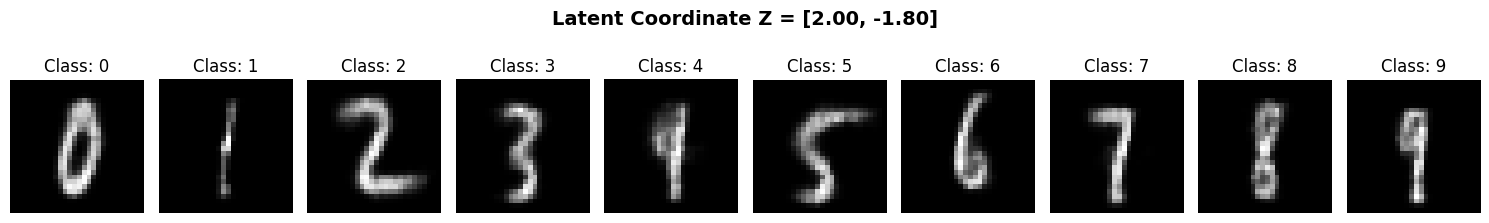

In [150]:
generate_digits_from_coordinate(model, [2, -1.8])